## Existing Fixed Canaries (Baseline)

The FFF framework selects a seed image from a finite pool (e.g., zebra, elephant, checkerboard) and optimizes its pixels via backpropagation through a frozen YOLOv8 detector. Below are the **seed canary images** from `InitImages/`. These are the starting points — and the finite set an adaptive attacker can enumerate and defeat.

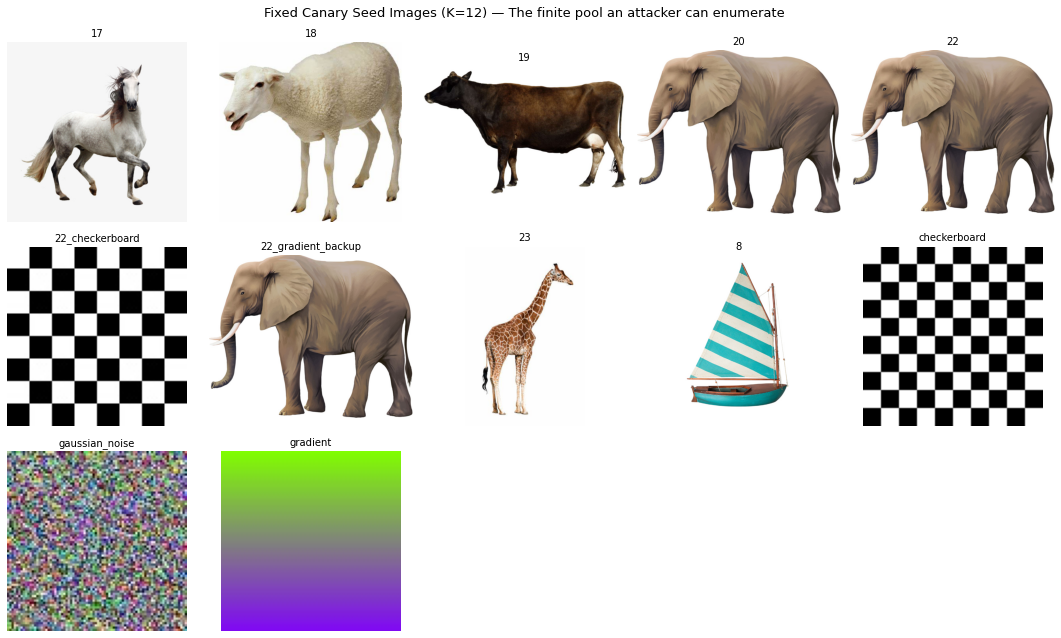

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# Path to seed canary images
init_root = '../InitImages'

# Collect all image files (skip subdirectories)
img_files = sorted([
    f for f in os.listdir(init_root)
    if f.lower().endswith(('.jpg', '.jpeg', '.png')) and os.path.isfile(os.path.join(init_root, f))
])

n = len(img_files)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
if rows == 1:
    axes = [axes] if n == 1 else list(axes)
else:
    axes = list(axes.flat)

for i, fname in enumerate(img_files):
    img = cv2.imread(os.path.join(init_root, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    name = os.path.splitext(fname)[0]
    axes[i].set_title(name, fontsize=10)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Fixed Canary Seed Images (K={n}) — The finite pool an attacker can enumerate', fontsize=13)
plt.tight_layout()
plt.show()

## Training a Fixed Canary (Class 17 — Horse)

Below we train a **fixed canary** using the existing FFF pipeline as a baseline. The canary is initialized from `InitImages/17.jpg` (horse) and optimized for 50 epochs with:
- Loss: $\mathcal{L} = 2.0 \cdot \mathcal{L}_{benign} - \mathcal{L}_{adv}$
- Optimizer: Adam, lr=1e-3, batch size=5
- Detector: Frozen YOLOv8n

After training, we evaluate on the 3 test images in `hady_test_samples/`:
- `sample.jpg` — benign (no attack) → expect **no attack detected**
- `sample_adv.jpg` — single person with adversarial patch → expect **attack detected**
- `sample2.jpg` — multiple people with adversarial patches → expect **attack detected**

Loading YOLOv8 detector...


YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Canary initialized (class 17, size 80x80)
Training for 50 epochs, batch_size=5, lr=0.001, weight=2.0
Save path: ./canary_cls17_training

--- Training ---


canary_2.0 epoch: 50/50: 100%|##########| 50/50 [04:21<00:00,  5.23s/it, b_box=0.2454, b_cls=6.4565, b_dfl=0.9047, b_loss=38.0330, a_box=1.9958, a_cls=9.8721, a_dfl=1.6567, a_loss=67.6233]      

Training complete!


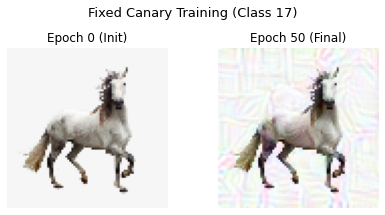


--- Evaluation on hady_test_samples ---
Load canary(17) for eval: ./canary_cls17_training\canary_050.png
  sample.jpg: is_attack = False
  sample2.jpg: is_attack = True
  sample_adv.jpg: is_attack = True


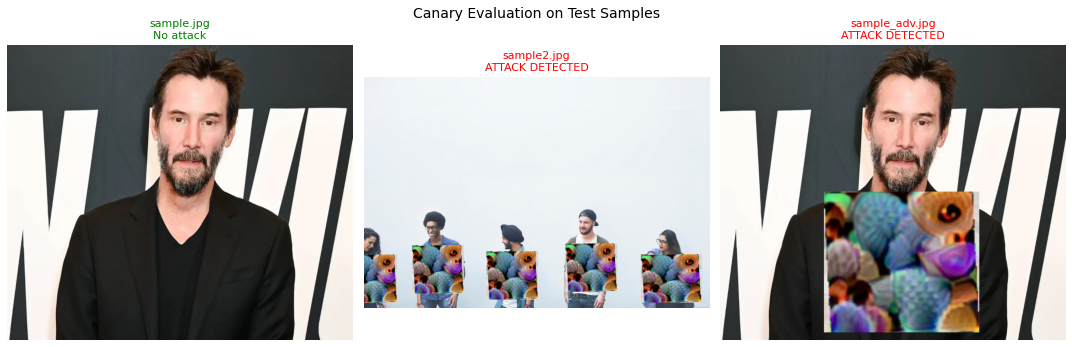

In [9]:
import sys
import os
import cv2
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from types import SimpleNamespace

# Add parent directory to path so we can import from the FFF codebase
sys.path.insert(0, os.path.abspath('..'))

from YOLOv8_Combiner import Canary, freeze_seed
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# ---- Configuration ----
cfg = SimpleNamespace(
    # Canary settings
    canary_cls_id=17,                  # horse
    canary_size=80,
    canary_init=True,
    canary_init_path='../InitImages/',
    # Training settings
    weight=2.0,                        # lambda_c
    epoch=50,
    learing_rate=1e-3,
    epoch_save=10,
    batch_size=5,
    # Data paths
    benign_root='../Data/traineval/VOC07_YOLOv8/train_120/benign',
    benign_label_root='../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
    adversarial_root='../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
    data_name='VOC07_120',
    # Detection settings
    img_size=640,
    person_conf=0.05,
    overlap_thresh=0.4,
    defensive_patch_location='cc',
    eval_no_overlap=True,
    margin_size=0,
    faster=False,
    # Misc
    num_works=0,                       # 0 workers for notebook compatibility
    seed=301,
    detect_name='yolov8',
    attack_name='fool',
)

freeze_seed(cfg.seed)

# ---- Initialize detector and canary ----
print("Loading YOLOv8 detector...")
detector = YOLOv8()

canary = Canary(cfg, detector)
canary.init_dataloader()
canary.init_canary()

# Override save path to keep outputs in this folder
canary.canary_save_path = './canary_cls17_training'
os.makedirs(canary.canary_save_path, exist_ok=True)
canary.save_canary(0)  # save initial canary

print(f"Canary initialized (class {cfg.canary_cls_id}, size {cfg.canary_size}x{cfg.canary_size})")
print(f"Training for {cfg.epoch} epochs, batch_size={cfg.batch_size}, lr={cfg.learing_rate}, weight={cfg.weight}")
print(f"Save path: {canary.canary_save_path}")

# ---- Train ----
print("\n--- Training ---")
canary.train()
print("Training complete!")

# IMPORTANT: Reset model to eval mode after training
# Training leaves the model in .train() mode which changes the output format
detector.model.eval()

# ---- Show initial vs final canary ----
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
init_img = cv2.imread(os.path.join(canary.canary_save_path, 'canary_000.png'))
init_img = cv2.cvtColor(init_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(init_img)
axes[0].set_title('Epoch 0 (Init)')
axes[0].axis('off')

final_img = cv2.imread(os.path.join(canary.canary_save_path, f'canary_{str(cfg.epoch).zfill(3)}.png'))
final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
axes[1].imshow(final_img)
axes[1].set_title(f'Epoch {cfg.epoch} (Final)')
axes[1].axis('off')

fig.suptitle(f'Fixed Canary Training (Class {cfg.canary_cls_id})', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Evaluate on hady_test_samples ----
print("\n--- Evaluation on hady_test_samples ---")
final_canary_path = os.path.join(canary.canary_save_path, f'canary_{str(cfg.epoch).zfill(3)}.png')
canary.eval_load_canary(canary_path=final_canary_path, canary_cls_id=cfg.canary_cls_id)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack}")

fig.suptitle('Canary Evaluation on Test Samples', fontsize=14)
plt.tight_layout()
plt.show()

# Generative Canary Defense for Object Detectors

## Motivation

The original **Fight Fire with Fire (FFF)** framework defends object detectors against adversarial patch attacks by inserting fixed "canary" patches (e.g., a zebra image) near suppressed bounding boxes. If the detector fails to see the canary, an adversarial attack is detected.

**Problem:** A fixed pool of K canaries is vulnerable to adaptive attackers who can optimize a single adversarial patch to suppress all K canaries simultaneously.

**Our extension:** Replace the fixed canary with a lightweight **generator network** $G_\theta(z, b)$ that produces a **unique** 80x80x3 canary patch for every image at inference time. The attacker can never predict which canary will appear.

## Generator Architecture (~200K parameters)

**Input:** $z = [\eta \| b] \in \mathbb{R}^{36}$ where:
- $\eta \sim \mathcal{N}(0, I_{32})$ — 32-dim random noise
- $b = (x_1, y_1, x_2, y_2)_{\text{normalized}}$ — bounding box coordinates

**Layers:**
1. FC: 36 → 256, ReLU
2. FC: 256 → 512, ReLU
3. FC: 512 → 1024, ReLU
4. Reshape to 16 x 8 x 8
5. ConvTranspose2d: 16 → 8, kernel 4, stride 2, pad 1 → 8 x 16 x 16
6. ConvTranspose2d: 8 → 3, kernel 4, stride 2, pad 1 → 3 x 32 x 32
7. Sigmoid activation → pixels in [0, 1]
8. Bilinear interpolation → final 80 x 80 patch

Using device: cuda
Generator parameters: 668,811


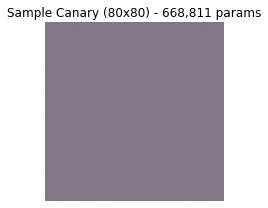

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


class GenerativeCanary(nn.Module):
    """Lightweight generator that produces unique 80x80x3 canary patches.
    
    Input:  z = [eta || b] in R^36
            eta ~ N(0, I_32)  (random noise)
            b = (x1, y1, x2, y2)  (normalized bbox coords)
    Output: canary patch of shape (3, 80, 80) with pixels in [0, 1]
    """

    def __init__(self, z_dim=32, bbox_dim=4, canary_size=80):
        super().__init__()
        self.z_dim = z_dim
        self.bbox_dim = bbox_dim
        self.canary_size = canary_size
        input_dim = z_dim + bbox_dim  # 36

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
        )

        # Transposed convolution layers
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(8, 3, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z):
        """Generate canary patch(es).
        
        Args:
            z: (batch, 36) concatenated [noise | bbox_coords]
        Returns:
            canary: (batch, 3, 80, 80) pixel values in [0, 1]
        """
        x = self.fc(z)                # (batch, 1024)
        x = x.view(-1, 16, 8, 8)     # (batch, 16, 8, 8)
        x = self.deconv(x)            # (batch, 3, 32, 32)
        # Bilinear interpolation to target size
        x = F.interpolate(x, size=(self.canary_size, self.canary_size), mode='bilinear', align_corners=False)
        return x


# --- Generate and display a sample canary ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

generator = GenerativeCanary().to(device)
num_params = sum(p.numel() for p in generator.parameters())
print(f'Generator parameters: {num_params:,}')

# Sample random noise + fake bbox coords
eta = torch.randn(1, 32, device=device)           # random noise
bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)  # normalized bbox
z = torch.cat([eta, bbox], dim=1)                  # (1, 36)

with torch.no_grad():
    canary = generator(z)  # (1, 3, 80, 80)

# Display
canary_img = canary[0].cpu().permute(1, 2, 0).numpy()  # (80, 80, 3)
plt.figure(figsize=(3, 3))
plt.imshow(canary_img)
plt.title(f'Sample Canary (80x80) - {num_params:,} params')
plt.axis('off')
plt.tight_layout()
plt.show()